In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df= pd.read_csv("Dataset .csv")

In [11]:
df= df.dropna(subset=['Cuisines'])

In [13]:
df['Cuisines List']= df ['Cuisines'].str.split(', ')

In [15]:
from itertools import chain

In [30]:
all_cuisines = list(chain.from_iterable(df['Cuisines List']))

In [32]:
from collections import Counter

In [34]:
cuisine_counts = Counter(all_cuisines)

In [36]:
cuisine_df = pd.DataFrame(cuisine_counts.items(), columns=['Cuisine', 'Count'])

In [38]:
cuisine_df = cuisine_df.sort_values(by='Count', ascending=False)

In [40]:
top_3 = cuisine_df.head(3)

In [44]:
print("Top 3 Cuisine:")
print(top_3)

Top 3 Cuisine:
         Cuisine  Count
81  North Indian   3960
9        Chinese   2735
19     Fast Food   1986


In [48]:
total_restaurants = len(df)
top_3['Percentage'] = (top_3['Count'] / total_restaurants) * 100
print("\nPercentage of Top 3 Cuisines:")
print(top_3)


Percentage of Top 3 Cuisines:
         Cuisine  Count  Percentage
81  North Indian   3960   41.500734
9        Chinese   2735   28.662754
19     Fast Food   1986   20.813247


C:\Users\Abhishek\AppData\Local\Temp\ipykernel_18064\3510815074.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_3['Percentage'] = (top_3['Count'] / total_restaurants) * 100


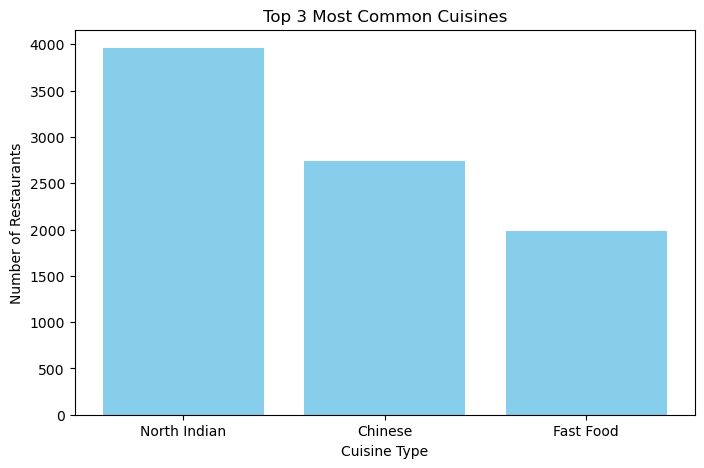

In [60]:
plt.figure(figsize=(8,5))
plt.bar(top_3['Cuisine'], top_3['Count'], color='skyblue')
plt.title("Top 3 Most Common Cuisines")
plt.ylabel("Number of Restaurants")
plt.xlabel("Cuisine Type")
plt.show()

In [62]:
# find the city with the highest number of resturents

In [72]:
df_city = df.dropna(subset=['City' or 'Aggregate rating'])
city_counts = df_city['City'].value_counts()
top_city = city_counts.idxmax()
top_city_count = city_counts.max()
print(f"City with the highest number of restaurants: {top_city} ({top_city} restaurants)")

City with the highest number of restaurants: New Delhi (New Delhi restaurants)


In [74]:
#Calculate the average rating for each city

In [78]:
avg_rating_per_city = df_city.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)
print("\nAverage rating for each city (Top 5 shown):")
print(avg_rating_per_city.head())


Average rating for each city (Top 5 shown):
City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Name: Aggregate rating, dtype: float64


In [80]:
# Identify the city with the highest average rating

In [86]:
highest_avg_rating_city = avg_rating_per_city.idxmax()
highest_avg_rating = avg_rating_per_city.max()
print(f"\nCity with the highest average rating: {highest_avg_rating_city} ({highest_avg_rating:.2f})")


City with the highest average rating: Inner City (4.90)


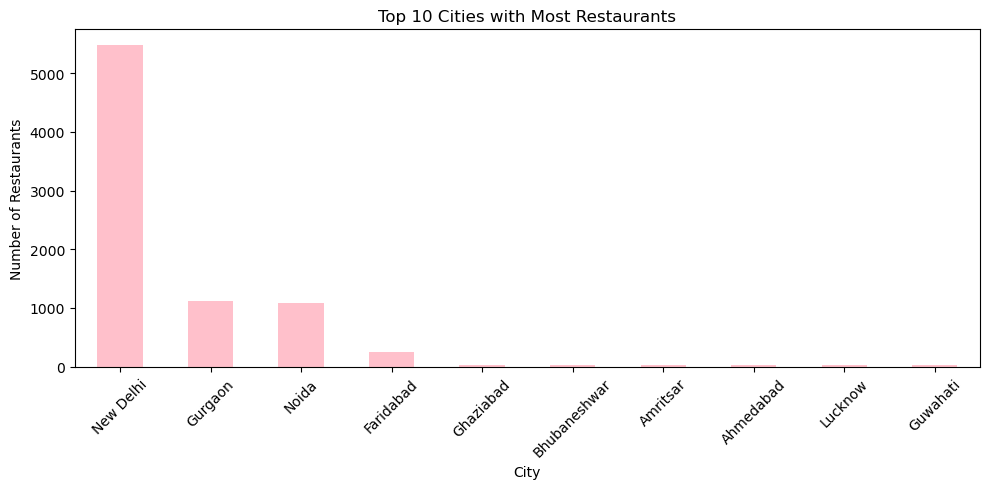

In [14]:
# Visualize the top 10 cities by number of restaurants
city_counts = df['City'].value_counts()
top_10_cities = city_counts.head(10)
plt.figure(figsize=(10, 5))
top_10_cities.plot(kind='bar', color='pink')
plt.title("Top 10 Cities with Most Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# count each price range

Percentage of Restaurants by Price Range Offering Services:
             Online Delivery (%)  Table Booking (%)
Price range                                        
1                      15.774077           0.022502
2                      41.310633           7.677482
3                      29.190341          45.738636
4                       9.044369          46.757679


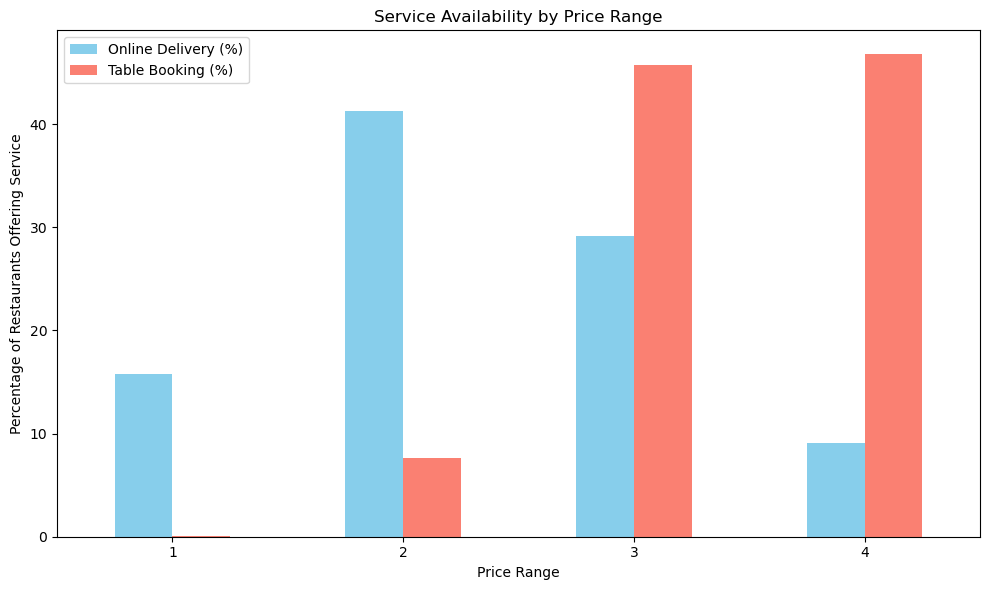

In [12]:
df.columns = df.columns.str.strip()
df_clean = df.dropna(subset=['Price range', 'Has Online delivery', 'Has Table booking'])
df_clean['Has Online delivery'] = df_clean['Has Online delivery'].astype(str).apply(lambda x: 1 if 'Yes' in x else 0)
df_clean['Has Table booking'] = df_clean['Has Table booking'].astype(str).apply(lambda x: 1 if 'Yes' in x else 0)
grouped = df_clean.groupby('Price range')[['Has Online delivery', 'Has Table booking']].mean() * 100
grouped = grouped.rename(columns={
    'Has Online delivery': 'Online Delivery (%)',
    'Has Table booking': 'Table Booking (%)'
})
print("Percentage of Restaurants by Price Range Offering Services:")
print(grouped)
grouped.plot(kind='bar', figsize=(10,6), color=['skyblue', 'salmon'])
plt.title("Service Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants Offering Service")
plt.xticks(rotation=0)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [98]:
#calculate percentage
price_percentage = (price_counts / len(df_price)) * 100

In [102]:
# Display results as a DataFrame
price_df = pd.DataFrame({
    'Price Range': price_counts.index,
    'Count': price_counts.values,
    'Percentage': price_percentage.values
})
print("Price Range Distribution")
print(price_df)

Price Range Distribution
   Price Range  Count  Percentage
0            1   4438   46.510166
1            2   3113   32.624188
2            3   1405   14.724376
3            4    586    6.141270


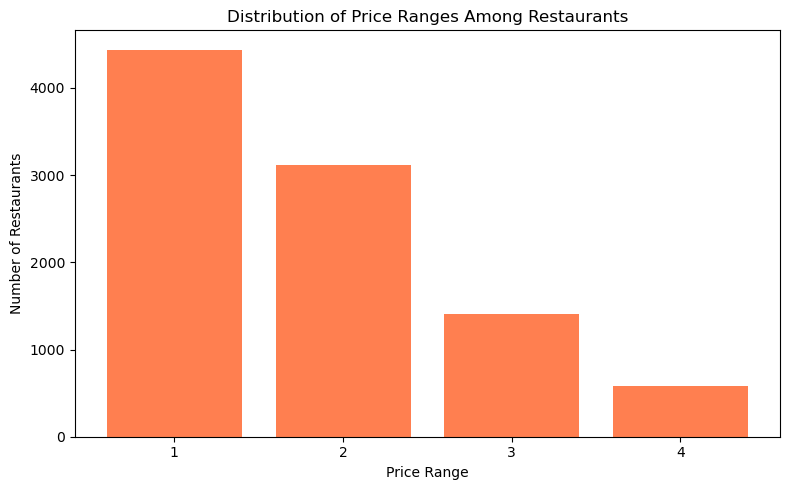

In [106]:
# Plot the bar chart
plt.figure(figsize=(8, 5))
plt.bar(price_df['Price Range'].astype(str), price_df['Count'], color='coral')
plt.title("Distribution of Price Ranges Among Restaurants")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.tight_layout()
plt.show()

In [26]:
df_delivery = df.dropna(subset=['Has Online delivery', 'Aggregate rating'])
df_delivery['Has Online delivery'] = df_delivery['Has Online delivery'].astype(str)
df_delivery['Has Online delivery'] = df_delivery['Has Online delivery'].apply(lambda x: 1 if 'Yes' in x else 0)
online_delivery_counts = df_delivery['Has Online delivery'].value_counts()
total_delivery = online_delivery_counts.sum()
online_count = online_delivery_counts.get(1, 0)
offline_count = online_delivery_counts.get(0, 0)
percentage_online_delivery = (online_count / total_delivery) * 100
percentage_no_delivery = (offline_count / total_delivery) * 100
avg_rating_online = df_delivery[df_delivery['Has Online delivery'] == 1]['Aggregate rating'].mean()
avg_rating_offline = df_delivery[df_delivery['Has Online delivery'] == 0]['Aggregate rating'].mean()
print(f"Online Delivery: {online_count} ({percentage_online_delivery:.2f}%)")
print(f"No Online Delivery: {offline_count} ({percentage_no_delivery:.2f}%)")
print(f"Average Rating (Online Delivery): {avg_rating_online:.2f}")
print(f"Average Rating (No Delivery): {avg_rating_offline:.2f}")

Online Delivery: 2451 (25.66%)
No Online Delivery: 7100 (74.34%)
Average Rating (Online Delivery): 3.25
Average Rating (No Delivery): 2.47
